# 12 제품 수요패턴 · RIDR 분석

논문 3장 스타일의 **제품(시계열) 수요패턴 분석** — 11장 SBC/ML 비교의 **변동성 근거**를 제공합니다.

| 분석 | 내용 |
|------|------|
| System / SKU-Level | type별·클러스터별 기초통계 (Table 3.2 스타일) |
| **CV** | 표준편차/평균 — 규모를 제거한 **순수 변동성** |
| **RIDR** | `(P90 − P10) / median` — 클러스터 내 수요 분산의 상대적 폭 |
| 수요 밴드 | 클러스터별 10–90% 밴드 시각화 |

> Ecuador: 논문 Center **B**(고변동) / **A**(저변동) → 본 데이터 **type B·E** / **type D**  
> 11장 결과: **B,E → SBC 우세**, **D → ML 우세** → 본 장에서 **변동 구조(RIDR·CV)** 로 뒷받침

**선행**: 05(SBC), 06(ML), 11(가중 WMAPE) | 분석 단위: **type × family** (165 시계열)

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))

from utils.paths import DATA_PROCESSED, SBC_CLUSTER, ML_CLUSTER
from utils.splits import TRAIN_WEEK_MAX
from utils.stats_summary import system_level_weekly_stats, sku_level_weekly_stats
from utils.pattern_analysis import (
    merge_cluster_labels,
    compute_system_level_cluster_stats,
    compute_sku_level_cluster_summary,
    compute_ridr_summary_by_type,
    band_percentile_summary,
    plot_cluster_bands_by_type,
)
from utils.sbc import CLUSTER_LABELS

dfw = pd.read_parquet(DATA_PROCESSED / 'df_weekly.parquet')
sbc = pd.read_parquet(SBC_CLUSTER)
ml = pd.read_parquet(ML_CLUSTER) if ML_CLUSTER.exists() else None
df = merge_cluster_labels(dfw, sbc, ml)

types = sorted(dfw['type'].unique())
# 11장: B,E 고변동→SBC / D 저변동→ML — 논문 Center B vs A 시각화 대응
COMPARE_TYPES = ['B', 'D']
print('types:', types, '| band 비교:', COMPARE_TYPES)

types: ['A', 'B', 'C', 'D', 'E'] | band 비교: ['B', 'D']


## 1. System-Level / SKU-Level 기초통계 (type별)

In [2]:
system_rows, sku_rows, sku_detail_all = [], [], []
for t in types:
    system_rows.append(system_level_weekly_stats(dfw, t))
    sku_sum, sku_detail = sku_level_weekly_stats(dfw, t)
    sku_rows.append(sku_sum)
    sku_detail_all.append(sku_detail)

system_stats = pd.concat(system_rows, ignore_index=True)
sku_stats = pd.concat(sku_rows, ignore_index=True)
sku_detail = pd.concat(sku_detail_all, ignore_index=True)

print('=== System-Level (type별 주간 총판매) ===')
display(system_stats.round(3))
print('\n=== SKU-Level 요약 (type별 family 시계열) ===')
display(sku_stats.round(3))

=== System-Level (type별 주간 총판매) ===


,type,level,n_weeks,mean,median,std,variance,cv,skewness,kurtosis,min,max
0,A,system,242,1458858.850,1566611.124,432935.975,1.874336e+11,0.297,-0.094,-1.106,454496.279,2537359.539
1,B,system,242,600250.558,607672.684,204724.240,4.191201e+10,0.341,0.201,-0.955,238151.426,1223427.936
2,C,system,242,679482.407,719666.369,175910.559,3.094452e+10,0.259,-0.120,-1.087,268354.749,1121222.554
3,D,system,242,1450757.425,1594141.125,442576.855,1.958743e+11,0.305,-0.220,-1.370,447442.409,2356329.393
4,E,system,242,247200.148,250152.746,105991.828,1.123427e+10,0.429,-0.049,-1.120,51409.921,526891.967



=== SKU-Level 요약 (type별 family 시계열) ===


,type,level,n_series,mean_of_mean,mean_of_std,mean_of_cv,median_of_mean
0,A,sku,33,44207.844,15313.534,0.648,3194.607
1,B,sku,33,18189.411,6925.121,0.622,781.025
2,C,sku,33,20590.376,6103.017,0.718,926.368
3,D,sku,33,43962.346,15215.849,0.619,3434.339
4,E,sku,33,7490.914,3450.062,0.868,283.492


## 2. SBC 클러스터별 System / SKU-Level 변동성 (type별)

In [3]:
sbc_sys_all, sbc_sku_all = [], []
for t in types:
    sub = df[df['type'] == t]
    _, sys_st = compute_system_level_cluster_stats(sub, 'SBC_CLUSTER')
    _, sku_st = compute_sku_level_cluster_summary(sub, 'SBC_CLUSTER')
    sys_st['type'] = t
    sku_st['type'] = t
    sbc_sys_all.append(sys_st)
    sbc_sku_all.append(sku_st)
    label = CLUSTER_LABELS.get(1, '')
    print(f'\n--- Type {t}: SBC System-Level ---')
    display(sys_st.round(3))
    print(f'--- Type {t}: SBC SKU-Level ---')
    display(sku_st.round(3))

sbc_system_by_type = pd.concat(sbc_sys_all, ignore_index=True)
sbc_sku_by_type = pd.concat(sbc_sku_all, ignore_index=True)


--- Type A: SBC System-Level ---


,SBC_CLUSTER,Mean,Median,Variance,Std_Dev,CV,Skewness,Kurtosis,type
0,1,1215698.031,1218737.654,7.264335e+10,269524.295,0.222,0.077,-0.222,A
1,2,28004.273,38814.500,4.698131e+08,21675.172,0.774,-0.326,-1.621,A
2,3,214428.294,311704.515,2.544288e+10,159508.229,0.744,-0.283,-1.619,A
3,4,728.252,266.500,5.049551e+06,2247.120,3.086,6.852,55.272,A


--- Type A: SBC SKU-Level ---


,SBC_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,19,63984.107,15797.245,0.243,1.001,0.071,0.001,A
1,2,8,3500.534,2850.049,0.864,1.546,0.752,0.351,A
2,3,3,71476.098,60036.748,0.931,1.014,0.885,0.014,A
3,4,2,364.126,1144.168,3.211,3.621,10.313,0.601,A



--- Type B: SBC System-Level ---


...

,SBC_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,19,62130.363,14825.545,0.234,1.001,0.067,0.001,D
1,2,9,3086.096,2471.509,0.959,1.838,1.041,0.397,D
2,3,3,80812.949,66021.637,0.841,1.014,0.711,0.014,D
3,4,2,33.403,64.588,2.411,3.621,6.516,0.622,D



--- Type E: SBC System-Level ---


,SBC_CLUSTER,Mean,Median,Variance,Std_Dev,CV,Skewness,Kurtosis,type
0,1,219761.498,228209.657,7.353130e+09,85750.393,0.390,-0.048,-0.882,E
1,2,25219.151,29078.062,4.373311e+08,20912.463,0.829,-0.168,-1.710,E
2,3,2134.020,1951.068,5.511863e+06,2347.736,1.100,4.469,24.790,E
3,4,85.479,24.500,8.575781e+04,292.844,3.426,5.365,30.661,E


--- Type E: SBC SKU-Level ---


,SBC_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,19,11566.395,4732.524,0.448,1.008,0.216,0.007,E
1,2,9,2802.128,2356.993,0.996,1.679,1.065,0.385,E
2,3,2,1067.010,1213.276,1.210,1.011,1.470,0.010,E
3,4,2,42.740,147.313,3.934,6.569,15.720,0.647,E


## 3. ML 클러스터별 System / SKU-Level 변동성 (type별)

In [4]:
ml_sys_all, ml_sku_all = [], []
if 'ML_CLUSTER' in df.columns:
    for t in types:
        sub = df[df['type'] == t]
        _, sys_st = compute_system_level_cluster_stats(sub, 'ML_CLUSTER')
        _, sku_st = compute_sku_level_cluster_summary(sub, 'ML_CLUSTER')
        sys_st['type'] = t
        sku_st['type'] = t
        ml_sys_all.append(sys_st)
        ml_sku_all.append(sku_st)
        print(f'\n--- Type {t}: ML System-Level ---')
        display(sys_st.round(3))
        print(f'--- Type {t}: ML SKU-Level ---')
        display(sku_st.round(3))
    ml_system_by_type = pd.concat(ml_sys_all, ignore_index=True)
    ml_sku_by_type = pd.concat(ml_sku_all, ignore_index=True)
else:
    print('ML_CLUSTER 없음 — 06 노트북을 먼저 실행하세요.')


--- Type A: ML System-Level ---


,ML_CLUSTER,Mean,Median,Variance,Std_Dev,CV,Skewness,Kurtosis,type
0,1,166234.629,165410.191,2.340877e+09,48382.607,0.291,1.300,3.883,A
1,2,733107.732,741898.500,3.904381e+10,197595.077,0.270,0.242,-0.534,A
2,3,190719.888,294157.285,2.363039e+10,153721.795,0.806,-0.372,-1.782,A
3,4,368796.601,375440.862,3.967962e+09,62991.763,0.171,-0.457,0.994,A


--- Type A: ML SKU-Level ---


,ML_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,24,6926.443,3015.586,0.766,1.401,1.234,0.168,A
1,2,2,366553.866,104384.152,0.303,1.000,0.101,0.000,A
2,3,1,190719.888,153721.795,0.806,1.043,0.650,0.041,A
3,4,5,73759.320,14096.491,0.189,1.000,0.039,0.000,A



--- Type B: ML System-Level ---

...

,ML_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,26,8055.455,2616.351,0.701,1.492,0.953,0.186,D
1,2,2,349691.101,97448.801,0.298,1.000,0.100,0.000,D
2,3,1,218525.975,176102.517,0.806,1.043,0.649,0.041,D
3,4,4,80851.854,15774.447,0.203,1.000,0.043,0.000,D



--- Type E: ML System-Level ---


,ML_CLUSTER,Mean,Median,Variance,Std_Dev,CV,Skewness,Kurtosis,type
0,1,104588.277,104782.597,2.243730e+09,47368.023,0.453,-0.154,-1.330,E
1,4,142611.871,142246.795,3.515640e+09,59292.835,0.416,0.109,-0.637,E


--- Type E: ML SKU-Level ---


,ML_CLUSTER,Series_Count,Mean_of_Mean,Mean_of_Std,Mean_of_CV,Mean_ADI,Mean_CV2,Mean_Zero_Ratio,type
0,1,30,3486.276,1781.669,0.896,1.58,1.589,0.164,E
1,4,2,71305.935,30200.992,0.436,1.00,0.195,0.000,E


## 4. RIDR 지수 · 클러스터 수요 밴드 (SBC)

RIDR = `(P90 − P10) / median` — 클러스터 내 시계열 수요 분산의 상대적 폭

=== SBC: RIDR Summary by Cluster (type별) ===
type               A       B       C       D       E
SBC_CLUSTER                                         
1              8.176   8.001   9.133   6.916   7.968
2              9.193  47.054  44.159   5.374  47.400
3             15.854   1.486   0.000  14.666   1.475
4            250.751   6.428  66.362   1.342  15.194

=== SBC: 10th/90th Percentile Band (mean over weeks) ===
                      p10        p90
type SBC_CLUSTER                    
A    1             335.62  152391.59
     2             576.70    7771.00
     3            3760.25  161439.64
     4               2.44     575.29
B    1             156.08   73966.70
     2              82.63   17103.91
     3             636.32    4478.22
     4              10.93     166.06
C    1             103.47   93505.55
     2              41.09   14957.74
     3            5551.64    5551.64
     4               0.13      63.58
D    1             428.22  149781.94
     2             383.1

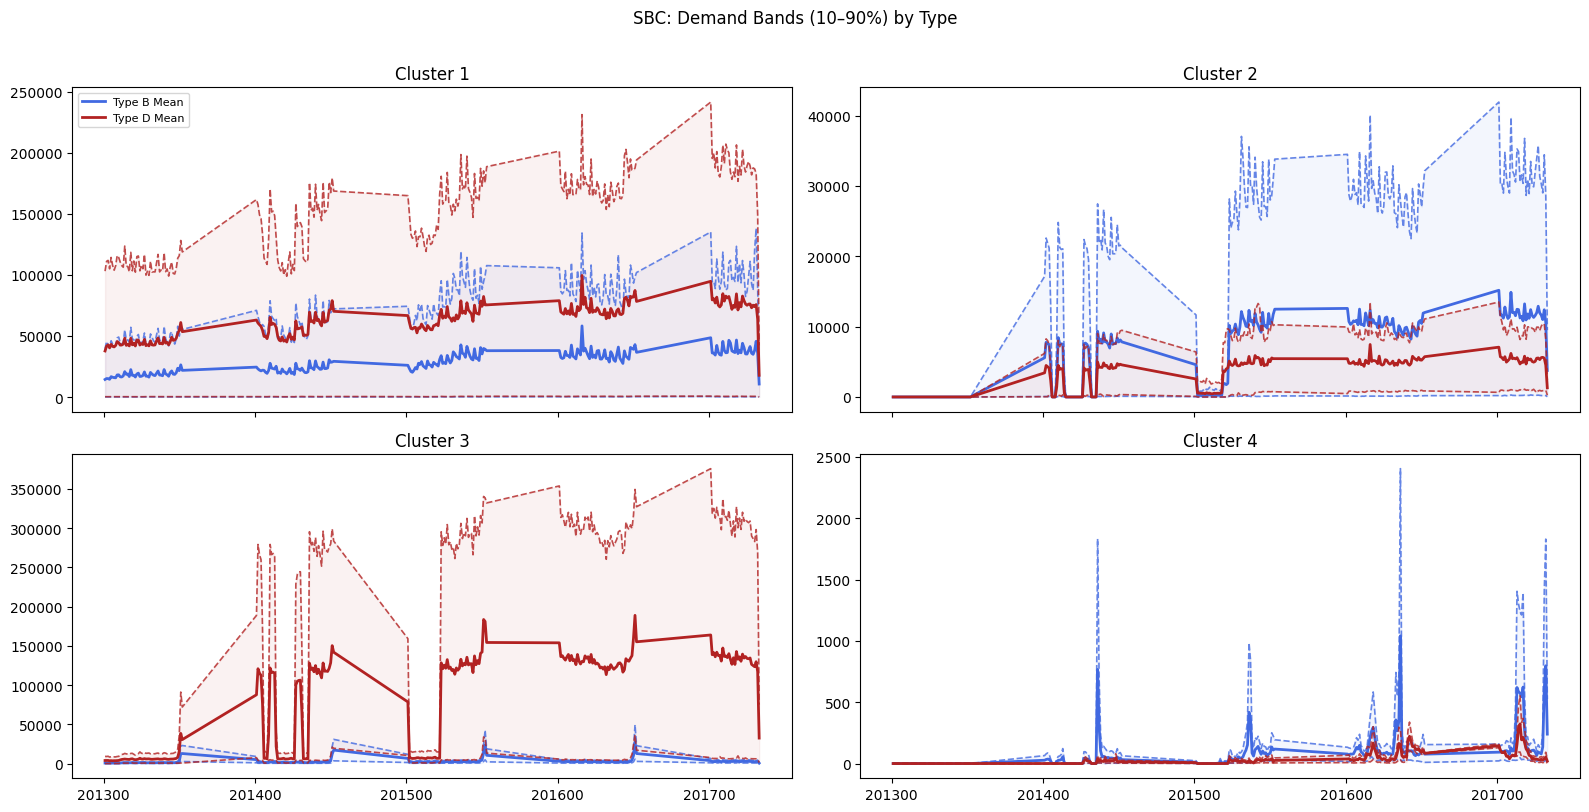

In [5]:
sbc_bands, sbc_ridr = compute_ridr_summary_by_type(df, 'SBC_CLUSTER')
print('=== SBC: RIDR Summary by Cluster (type별) ===')
print(sbc_ridr.round(3))
print('\n=== SBC: 10th/90th Percentile Band (mean over weeks) ===')
print(band_percentile_summary(sbc_bands, 'SBC_CLUSTER', 'type'))

fig = plot_cluster_bands_by_type(
    sbc_bands, 'SBC_CLUSTER', types_to_plot=COMPARE_TYPES, method_label='SBC'
)
plt.show()

## 5. RIDR 지수 · 클러스터 수요 밴드 (ML)

=== ML: RIDR Summary by Cluster (type별) ===
type             A       B       C       D       E
ML_CLUSTER                                        
1           71.964  62.674  71.552  39.570  86.406
2            0.351     NaN   0.000   0.336     NaN
3            0.000     NaN     NaN   0.000     NaN
4            1.004   1.220   0.994   0.763   0.338

=== ML: 10th/90th Percentile Band (mean over weeks) ===
                       p10        p90
type ML_CLUSTER                      
A    1               52.58   23235.20
     2           310695.23  422412.50
     3           190719.89  190719.89
     4            48439.16  107865.38
B    1               30.73   17783.76
     4            73861.34  201395.76
C    1                9.77   18415.03
     2           265566.61  265566.61
     4            44930.59  126821.05
D    1               43.04   25968.13
     2           299931.30  399450.90
     3           218525.98  218525.98
     4            51106.21  110609.26
E    1                4

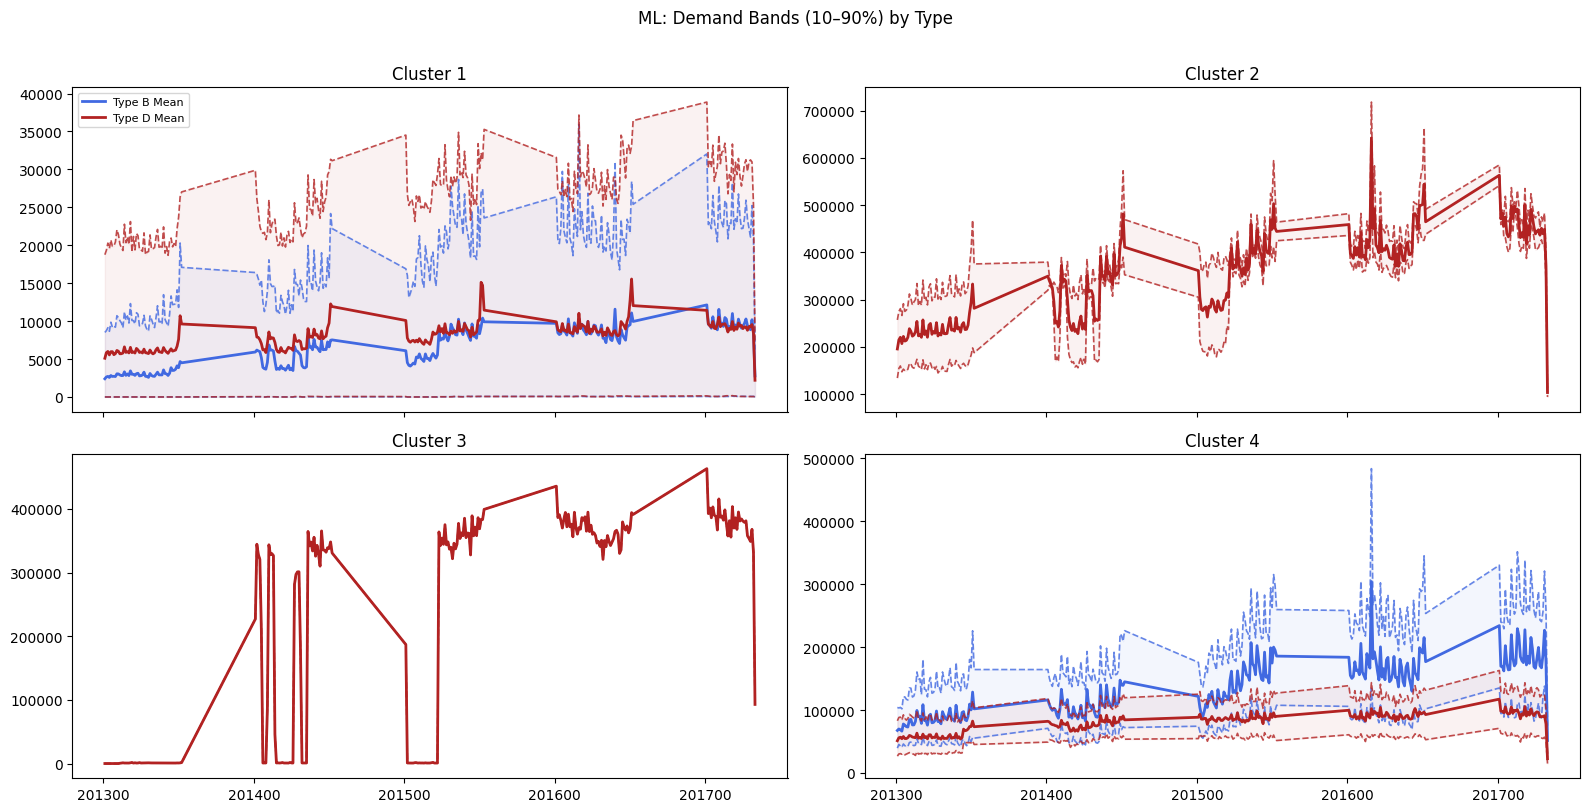

In [6]:
if 'ML_CLUSTER' in df.columns:
    ml_bands, ml_ridr = compute_ridr_summary_by_type(df, 'ML_CLUSTER')
    print('=== ML: RIDR Summary by Cluster (type별) ===')
    print(ml_ridr.round(3))
    print('\n=== ML: 10th/90th Percentile Band (mean over weeks) ===')
    print(band_percentile_summary(ml_bands, 'ML_CLUSTER', 'type'))
    fig = plot_cluster_bands_by_type(
        ml_bands, 'ML_CLUSTER', types_to_plot=COMPARE_TYPES, method_label='ML'
    )
    plt.show()

In [7]:
out = DATA_PROCESSED
system_stats.to_csv(out / 'type_system_level_stats.csv', index=False)
sku_stats.to_csv(out / 'type_sku_level_stats.csv', index=False)
sku_detail.to_csv(out / 'type_family_series_stats.csv', index=False)
sbc_system_by_type.to_csv(out / 'sbc_system_level_by_type.csv', index=False)
sbc_sku_by_type.to_csv(out / 'sbc_sku_level_by_type.csv', index=False)
sbc_ridr.to_csv(out / 'sbc_ridr_by_type.csv')
sbc_bands.to_parquet(out / 'sbc_cluster_bands.parquet', index=False)

if 'ML_CLUSTER' in df.columns:
    ml_system_by_type.to_csv(out / 'ml_system_level_by_type.csv', index=False)
    ml_sku_by_type.to_csv(out / 'ml_sku_level_by_type.csv', index=False)
    ml_ridr.to_csv(out / 'ml_ridr_by_type.csv')
    ml_bands.to_parquet(out / 'ml_cluster_bands.parquet', index=False)

print('저장 완료:', out)

저장 완료: C:\Users\kjh\ai-retail-demandforecasting\data\processed


## 6. 11장 하이브리드 결과와 연계

type별 **CV·RIDR**과 11장 **가중 WMAPE 우세 scheme**을 나란히 대조합니다.

In [8]:
from utils.phase_analysis import (
    validation_weights, build_family_from_phase2_best, compare_schemes_by_type,
)

train = dfw[dfw['yearweek'] <= TRAIN_WEEK_MAX]

fam_cv = train.groupby(['type', 'family'])['sales'].apply(
    lambda s: s.std() / s.mean() if s.mean() > 0 else np.nan
).groupby('type').mean()

sbc_ridr_mean = sbc_ridr.mean(axis=0)
ml_ridr_mean = ml_ridr.mean(axis=0) if 'ML_CLUSTER' in df.columns else pd.Series(dtype=float)

p2 = pd.read_parquet(DATA_PROCESSED / 'phase2_results.parquet')
p2b = pd.read_csv(DATA_PROCESSED / 'phase2_best_per_condition.csv')
tc = compare_schemes_by_type(
    build_family_from_phase2_best(p2, p2b, validation_weights(dfw))
)

link = pd.DataFrame({
    'cv_family_mean': fam_cv.round(3),
    'system_cv': system_stats.set_index('type')['cv'].round(3),
    'sbc_ridr_mean': sbc_ridr_mean.round(2),
    'ml_ridr_mean': ml_ridr_mean.round(2),
    'wmape_winner': tc['better_scheme_weighted'],
    'sbc_wmape': tc['SBC_wmape_weighted'],
    'ml_wmape': tc['ML_wmape_weighted'],
})
display(link)

print('\n[해석 요약]')
print('- B,E: CV·RIDR 높음 → 11장 SBC 우세와 방향 일치')
print('- D: CV·RIDR 상대적 낮음 → 11장 ML 우세와 방향 일치')
print('- C: CV 최고이나 ML 우세 — RIDR·CV만으로 scheme 결정 불가 (11장 예외)')
print('- 모든 데이터에 항상 성립하지 않으나, 변동성 지표로 scheme 선택 근거를 보완')

,cv_family_mean,system_cv,sbc_ridr_mean,ml_ridr_mean,wmape_winner,sbc_wmape,ml_wmape
A,0.621,0.297,70.99,18.33,SBC,33.90,35.93
B,0.622,0.341,15.74,31.95,SBC,27.07,28.55
C,0.719,0.259,29.91,24.18,ML,33.33,32.89
D,0.617,0.305,7.07,10.17,ML,37.78,37.44
E,0.868,0.429,18.01,43.37,SBC,27.89,28.92



[해석 요약]
- B,E: CV·RIDR 높음 → 11장 SBC 우세와 방향 일치
- D: CV·RIDR 상대적 낮음 → 11장 ML 우세와 방향 일치
- C: CV 최고이나 ML 우세 — RIDR·CV만으로 scheme 결정 불가 (11장 예외)
- 모든 데이터에 항상 성립하지 않으나, 변동성 지표로 scheme 선택 근거를 보완


### 종합 해석

1. **System-Level CV** — type 전체 주간 총판매의 변동성. E·B가 상대적으로 높고 D·A가 낮음.
2. **SKU-Level CV / RIDR** — 클러스터 내 제품 수요 분포의 퍼짐. SBC cluster 2·4에서 B·C·E type RIDR이 크게 나타남 (간헐·루미 패턴).
3. **ML RIDR** — cluster 1에 고변동이 집중, 나머지 cluster는 저변동 → ML scheme의 균일한 저변동 세분화.
4. **11장 연계** — 고변동 type(B,E)에서 SBC(rule-base) 우세, 저변동 type(D)에서 ML 우세는 논문 Center B/A 스토리와 **부분적으로 정합**. 단, C type 등 **예외**가 있어 CV·RIDR은 **필요조건에 가깝고 충분조건은 아님**.
5. **한계** — Ecuador 5 type·165 시계열에 한정; 다른 산업·기간·클러스터 수에서는 결과가 달라질 수 있음.